In [1]:
"""
06_exploratory_analysis.py

Compare healthy vs. failed observations on the financial ratios:
mean/median by group, correlations, Mann-Whitney U tests, and a
detailed leakage investigation of the "dgrmovestreet" behavioural
variable (missingness by year, recall among failures, and a
years-before-failure profile using the full historical panel).
"""


'\n06_exploratory_analysis.py\n\nCompare healthy vs. failed observations on the financial ratios:\nmean/median by group, correlations, Mann-Whitney U tests, and a\ndetailed leakage investigation of the "dgrmovestreet" behavioural\nvariable (missingness by year, recall among failures, and a\nyears-before-failure profile using the full historical panel).\n'

In [2]:
from utils.load_data_features import load_data_features

df = load_data_features()


In [3]:
import pandas as pd
from scipy.stats import mannwhitneyu

from config import FEATURES_FINANCIAL, TARGET
from utils.print_section import print_section

print_section("Mean")
print(df.groupby(TARGET)[FEATURES_FINANCIAL].mean())

print_section("Median")
median_features = [f for f in FEATURES_FINANCIAL if f not in ("log_age", "size")]
print(df.groupby(TARGET)[median_features].median())

print_section("Correlations")
print(df[FEATURES_FINANCIAL].corr())

# ------------------------------------------------------------------
# Mann-Whitney U tests: is each feature's distribution significantly
# different between healthy (target=0) and failed (target=1) firms?
# ------------------------------------------------------------------
print_section("Mann-Whitney U tests")

results = []
for feature in FEATURES_FINANCIAL:
    healthy = df.loc[df[TARGET] == 0, feature].dropna()
    failed = df.loc[df[TARGET] == 1, feature].dropna()

    _, p_value = mannwhitneyu(healthy, failed, alternative="two-sided")

    results.append({
        "feature": feature,
        "p_value": p_value,
        "healthy_median": healthy.median(),
        "failed_median": failed.median(),
    })

print(pd.DataFrame(results))



Mean
        profitability  liquidity   solvency  structure   log_age       size
target                                                                     
0           -0.551703  20.432005 -40.185019   0.739950  2.443892  12.212406
1           -5.118872   5.505858 -64.104332   0.855212  2.323365  11.196500

Median
        profitability  liquidity  solvency  structure
target                                               
0            0.036218   1.500386  0.381471   0.892597
1           -0.154000   0.655377 -0.198374   0.991753

Correlations
               profitability  liquidity  solvency  structure   log_age  \
profitability       1.000000   0.000024 -0.373555  -0.002697  0.000853   
liquidity           0.000024   1.000000  0.000033  -0.000995  0.002359   
solvency           -0.373555   0.000033  1.000000   0.003654 -0.001844   
structure          -0.002697  -0.000995  0.003654   1.000000 -0.009260   
log_age             0.000853   0.002359 -0.001844  -0.009260  1.000000   
size    

         feature        p_value  healthy_median  failed_median
0  profitability   0.000000e+00        0.036218      -0.154000
1      liquidity   0.000000e+00        1.500386       0.655377
2       solvency   0.000000e+00        0.381471      -0.198374
3      structure   2.635645e-83        0.892597       0.991753
4        log_age   2.913947e-22        2.484907       2.302585
5           size  1.254591e-206       12.287828      11.343974


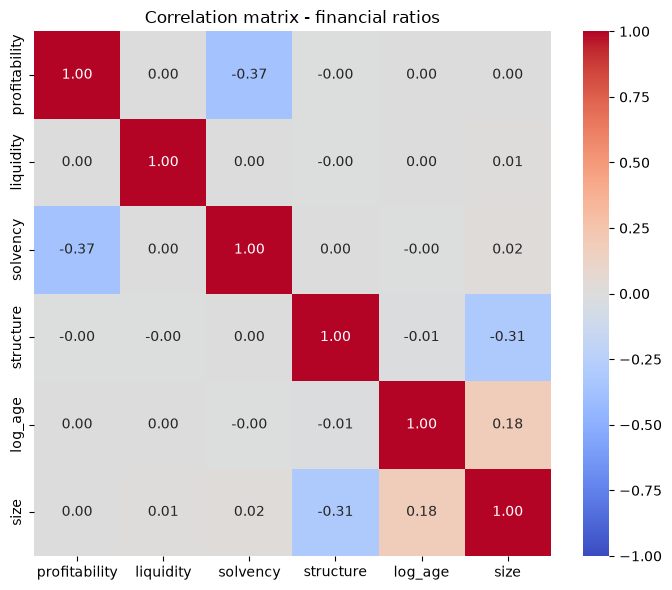

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

from config import FIGURES

FIGURES.mkdir(parents=True, exist_ok=True)

corr = df[FEATURES_FINANCIAL].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix - financial ratios")
fig.tight_layout()
fig.savefig(FIGURES / "correlation_heatmap.png", dpi=150)
plt.show()


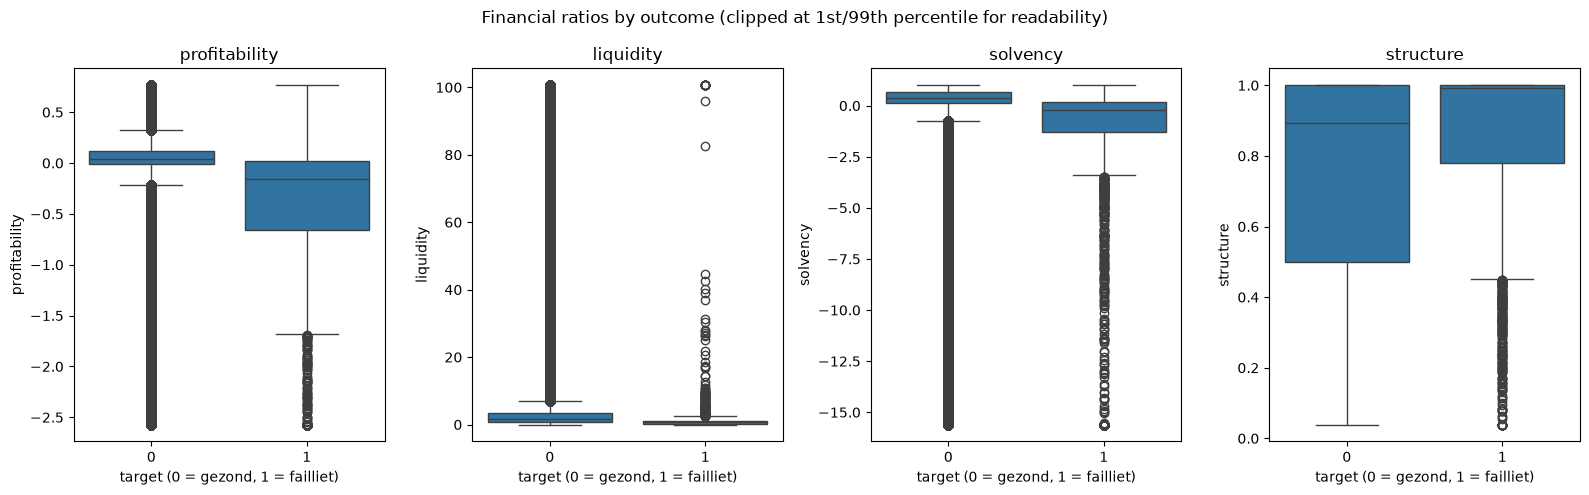

In [5]:
from config import WINSOR_COLUMNS, WINSOR_LOWER_QUANTILE, WINSOR_UPPER_QUANTILE

# Clipped copy purely for plotting - the raw ratios have extreme
# outliers (see 05_feature_engineering.py) that would make a boxplot
# unreadable. This does not touch the actual model data.
plot_df = df[WINSOR_COLUMNS + [TARGET]].copy()
for col in WINSOR_COLUMNS:
    lower = plot_df[col].quantile(WINSOR_LOWER_QUANTILE)
    upper = plot_df[col].quantile(WINSOR_UPPER_QUANTILE)
    plot_df[col] = plot_df[col].clip(lower, upper)

fig, axes = plt.subplots(1, len(WINSOR_COLUMNS), figsize=(4 * len(WINSOR_COLUMNS), 5))

for ax, col in zip(axes, WINSOR_COLUMNS):
    sns.boxplot(data=plot_df, x=TARGET, y=col, ax=ax)
    ax.set_xlabel("target (0 = gezond, 1 = failliet)")
    ax.set_title(col)

fig.suptitle("Financial ratios by outcome (clipped at 1st/99th percentile for readability)")
fig.tight_layout()
fig.savefig(FIGURES / "ratio_boxplots_by_target.png", dpi=150)
plt.show()


In [6]:
# ------------------------------------------------------------------
# dgrmovestreet leakage check
#
# We don't have the data vendor's exact construction logic for this
# variable, so this can't give 100% certainty - but each check below
# is a pattern we WOULD expect to see if the variable were
# contaminated with knowledge of the eventual failure outcome. We
# test whether that pattern actually holds in the data.
# ------------------------------------------------------------------
print_section("dgrmovestreet: missing rate and dgrmovestreet=1 rate, by bookyear")

print("Missing rate:")
print(df.groupby("bookyear")["dgrmovestreet"].apply(lambda s: s.isna().mean()))
print("\ndgrmovestreet=1 rate:")
print(df.groupby("bookyear")["dgrmovestreet"].mean())
print(
    "\n-> fully populated (0% missing) in every bookyear, including the most "
    "recent one (2019). If the variable required information that only "
    "becomes available in hindsight, we would expect more missingness in "
    "the most recent year - we don't see that."
)

print_section("How concentrated is dgrmovestreet=1 among failed observations?")

failed_rate = df.loc[df[TARGET] == 1, "dgrmovestreet"].mean()
healthy_rate = df.loc[df[TARGET] == 0, "dgrmovestreet"].mean()

print(f"dgrmovestreet=1 rate among failed rows : {failed_rate:.2%}")
print(f"dgrmovestreet=1 rate among healthy rows: {healthy_rate:.2%}")
print(
    f"\n-> only {failed_rate:.1%} of companies that actually fail show this flag "
    "in their failing year. If this variable were essentially a proxy for "
    "the outcome itself, we would expect that number to be much closer "
    "to 100%, not a small minority."
)

print_section("Signal strength vs. the other behavioural dummies")

for col in ["dgrmovestreet", "laat_dummy", "boete_dummy"]:
    ratio = df.loc[df[TARGET] == 1, col].mean() / df.loc[df[TARGET] == 0, col].mean()
    print(f"{col}: {ratio:.2f}x more common among failed than healthy observations")



dgrmovestreet: missing rate and dgrmovestreet=1 rate, by bookyear
Missing rate:
bookyear
2017    0.0
2018    0.0
2019    0.0
Name: dgrmovestreet, dtype: float64

dgrmovestreet=1 rate:
bookyear
2017    0.008091
2018    0.007873
2019    0.003743
Name: dgrmovestreet, dtype: float64

-> fully populated (0% missing) in every bookyear, including the most recent one (2019). If the variable required information that only becomes available in hindsight, we would expect more missingness in the most recent year - we don't see that.

How concentrated is dgrmovestreet=1 among failed observations?
dgrmovestreet=1 rate among failed rows : 6.06%
dgrmovestreet=1 rate among healthy rows: 0.64%

-> only 6.1% of companies that actually fail show this flag in their failing year. If this variable were essentially a proxy for the outcome itself, we would expect that number to be much closer to 100%, not a small minority.

Signal strength vs. the other behavioural dummies
dgrmovestreet: 9.44x more common amo

In [7]:
# ------------------------------------------------------------------
# The most informative check: does dgrmovestreet spike specifically in
# the year right before failure (which would suggest it's derived
# with knowledge of the upcoming failure date), or is it elevated
# throughout a failing company's whole history (consistent with a
# genuine, persistent instability trait)?
#
# This needs bookyears outside the 2017-2019 model sample, so we load
# the full cleaned panel just for this one check.
# ------------------------------------------------------------------
from utils.load_data_cleaned import load_data_cleaned

print_section("dgrmovestreet rate by years-before-failure (full panel, all bookyears)")

panel = load_data_cleaned()[["vat", "bookyear", "jaar_van_faling", "dgrmovestreet"]]

failing_company_rows = panel[panel["jaar_van_faling"].notna()].copy()
failing_company_rows["years_before_failure"] = (
    failing_company_rows["jaar_van_faling"] - failing_company_rows["bookyear"]
)

profile = (
    failing_company_rows[failing_company_rows["years_before_failure"].between(0, 6)]
    .groupby("years_before_failure")["dgrmovestreet"]
    .agg(["mean", "count"])
)
print(profile)

never_failed_vats = set(panel["vat"]) - set(failing_company_rows["vat"])
never_failed_rate = panel[panel["vat"].isin(never_failed_vats)]["dgrmovestreet"].mean()
print(f"\nCompanies that never fail (any bookyear): {never_failed_rate:.2%}")

print(
    "\n-> the rate is elevated (4-9%) across ALL years before failure, not "
    "just the final year - and it is actually HIGHER 2-3 years before "
    "failure than in the failing year itself. If dgrmovestreet were "
    "computed backward from a known failure date, we would expect the "
    "opposite: a spike concentrated right before failure. This pattern is "
    "more consistent with dgrmovestreet reflecting an underlying company "
    "instability trait that happens to correlate with future failure risk, "
    "not a variable contaminated with knowledge of the exact failure date.\n"
    "\n"
    "Conclusion: this does not fully rule out leakage (the vendor's exact "
    "construction logic is unknown to us), but the missingness pattern, "
    "the low recall among failures (~6%), and this multi-year profile "
    "together substantially weaken the leakage concern."
)



dgrmovestreet rate by years-before-failure (full panel, all bookyears)


                          mean  count
years_before_failure                 
0.0                   0.058333    120
1.0                   0.055422   3338
2.0                   0.090773   9320
3.0                   0.077943  10931
4.0                   0.062556  11126
5.0                   0.044633   9791
6.0                   0.035737   6352

Companies that never fail (any bookyear): 0.53%

-> the rate is elevated (4-9%) across ALL years before failure, not just the final year - and it is actually HIGHER 2-3 years before failure than in the failing year itself. If dgrmovestreet were computed backward from a known failure date, we would expect the opposite: a spike concentrated right before failure. This pattern is more consistent with dgrmovestreet reflecting an underlying company instability trait that happens to correlate with future failure risk, not a variable contaminated with knowledge of the exact failure date.

Conclusion: this does not fully rule out leakage (the vendor's exact 